# V1 ATS Analyzer


In [1]:
!pip install PyPDF2 pandas numpy nltk


In [2]:
import PyPDF2
import pandas as pd
import numpy as np
import nltk

from IPython.display import display

nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
skills_db=['python','java','sql','machine learning','tensorflow','pytorch','nlp']


In [4]:
skills_db = [

    "python",
    "java",
    "c",
    "c++",
    "sql",

    "machine learning",
    "deep learning",

    "tensorflow",
    "pytorch",

    "nlp",
    "bert",
    "huggingface",

    "aws",
    "docker",

    "git",
    "github",

    "linux",

    "pandas",
    "numpy",

    "scikit-learn",

    "opencv",

    "power bi",

    "excel",

    "data analysis",

    "data science"
]

In [5]:
def extract_text(pdf_path):

    text = ""

    with open(pdf_path, "rb") as file:

        reader = PyPDF2.PdfReader(file)

        for page in reader.pages:

            page_text = page.extract_text()

            if page_text:
                text += page_text

    return text

In [6]:
import os

for file in os.listdir():
    print(file)

AI_Powered_Resume_Screening_and_Candidate_Ranking_System.ipynb
Customer_Support_Chatbot
data_analysis_agent.ipynb
hand_gesture_and_age_detector.ipynb


In [7]:
resume_path = "Sahil_Prakash_Resume.pdf"

In [8]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\admin\Desktop\projects
['AI_Powered_Resume_Screening_and_Candidate_Ranking_System.ipynb', 'Customer_Support_Chatbot', 'data_analysis_agent.ipynb', 'hand_gesture_and_age_detector.ipynb']


In [10]:
resume_path = "Sahil_Prakash_Resume_Updated (2).pdf"

resume_text = extract_text(resume_path)

print(resume_text[:2000])

SAHIL PRAKASH
Computer Science Graduate | Python & ML Enthusiast | Software Developer
+91-8287462092 | sahilprakash4097@gmail.com  | github.com/Sahilp008 | linkedin.com/in/sahilprakash17
SUMMARY
B.Tech CSE graduate (2025) looking to apply hands-on experience in ML, NLP, and data analysis in a graduate trainee role. Proficient in Python, TensorFlow, PyTorch, and scikit-learn, with ML pipelines achieving up to 94% accuracy. Has basic understanding of AI agent concepts including prompt chaining, tool use, and workflow automation using Make.com and n8n. Currently upskilling through the McKinsey Forward Program and Anthropic AI courses on LLMs and AI agents.
TECHNICAL SKILLS
Languages: Python, C/C++, SQL, JavaML / AI: TensorFlow, PyTorch, scikit-learn, HuggingFace BERT, OpenCV, NLP, Deep LearningAutomation & Agents: Make.com, n8n, LLM prompt chaining, AI agent workflowsData: Pandas, NumPy, Matplotlib, Seaborn, EDA, Feature Engineering, Data CleaningTools: Git/GitHub, Jupyter Notebook, Googl

In [11]:
def extract_skills(text):

    text = text.lower()

    found = []

    for skill in skills_db:

        if skill in text:

            found.append(skill)

    return sorted(
        list(
            set(found)
        )
    )

In [12]:
resume_skills = extract_skills(
    resume_text
)

print("Resume Skills:\n")

for skill in resume_skills:

    print("✓", skill)

Resume Skills:

✓ aws
✓ bert
✓ c
✓ c++
✓ data analysis
✓ data science
✓ deep learning
✓ excel
✓ git
✓ github
✓ huggingface
✓ java
✓ machine learning
✓ nlp
✓ numpy
✓ opencv
✓ pandas
✓ python
✓ pytorch
✓ scikit-learn
✓ sql
✓ tensorflow


In [13]:
job_description = """

Python Developer

Required Skills:

Python
SQL
Machine Learning
TensorFlow
AWS
Git
Docker

Good Communication Skills

"""

print(job_description)



Python Developer

Required Skills:

Python
SQL
Machine Learning
TensorFlow
AWS
Git
Docker

Good Communication Skills




In [14]:
jd_skills = extract_skills(
    job_description
)

print("JD Skills:\n")

for skill in jd_skills:

    print("✓", skill)

JD Skills:

✓ aws
✓ c
✓ docker
✓ git
✓ machine learning
✓ python
✓ sql
✓ tensorflow


In [15]:
matched_skills = list(
    set(resume_skills)
    &
    set(jd_skills)
)

missing_skills = list(
    set(jd_skills)
    -
    set(resume_skills)
)

if len(jd_skills) == 0:

    ats_score = 0

else:

    ats_score = (
        len(matched_skills)
        /
        len(jd_skills)
    ) * 100

ats_score = round(
    ats_score,
    2
)

In [16]:
print("="*50)

print(
    f"ATS SCORE : {ats_score}%"
)

print("="*50)

print("\nMATCHED SKILLS\n")

for skill in matched_skills:

    print("✓", skill)

print("\nMISSING SKILLS\n")

for skill in missing_skills:

    print("✗", skill)

ATS SCORE : 87.5%

MATCHED SKILLS

✓ c
✓ python
✓ machine learning
✓ aws
✓ sql
✓ tensorflow
✓ git

MISSING SKILLS

✗ docker


In [18]:
def generate_suggestions():

    suggestions = []

    if ats_score >= 80:

        suggestions.append(
            "Excellent ATS Match."
        )

    elif ats_score >= 60:

        suggestions.append(
            "Good ATS Match."
        )

    else:

        suggestions.append(
            "Resume needs improvement."
        )

    if len(missing_skills) > 0:

        suggestions.append(
            "Consider adding these skills if you have experience:"
        )

        for skill in missing_skills:

            suggestions.append(
                f"- {skill}"
            )

    return suggestions

In [19]:
suggestions = generate_suggestions()

print(
    "\nRESUME SUGGESTIONS\n"
)

for item in suggestions:

    print(item)


RESUME SUGGESTIONS

Excellent ATS Match.
Consider adding these skills if you have experience:
- docker


In [20]:
summary = pd.DataFrame({

    "Metric":[

        "ATS Score",
        "Resume Skills",
        "JD Skills",
        "Matched Skills",
        "Missing Skills"

    ],

    "Value":[

        ats_score,

        len(resume_skills),

        len(jd_skills),

        len(matched_skills),

        len(missing_skills)

    ]

})

display(summary)

,Metric,Value
0,ATS Score,87.5
1,Resume Skills,22.0
2,JD Skills,8.0
3,Matched Skills,7.0
4,Missing Skills,1.0


In [21]:
results = {

    "ATS Score":ats_score,

    "Resume Skills":resume_skills,

    "JD Skills":jd_skills,

    "Matched Skills":matched_skills,

    "Missing Skills":missing_skills

}

print(results)

{'ATS Score': 87.5, 'Resume Skills': ['aws', 'bert', 'c', 'c++', 'data analysis', 'data science', 'deep learning', 'excel', 'git', 'github', 'huggingface', 'java', 'machine learning', 'nlp', 'numpy', 'opencv', 'pandas', 'python', 'pytorch', 'scikit-learn', 'sql', 'tensorflow'], 'JD Skills': ['aws', 'c', 'docker', 'git', 'machine learning', 'python', 'sql', 'tensorflow'], 'Matched Skills': ['c', 'python', 'machine learning', 'aws', 'sql', 'tensorflow', 'git'], 'Missing Skills': ['docker']}


In [22]:
from sentence_transformers import SentenceTransformer

print("BERT Loaded")

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BERT Loaded


In [23]:
!pip install sentence-transformers scikit-learn

In [24]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [25]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model Loaded")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4934.25it/s]


Model Loaded


In [26]:
resume_text = extract_text("Sahil_Prakash_Resume_Updated (1).pdf")

FileNotFoundError: [Errno 2] No such file or directory: 'Sahil_Prakash_Resume_Updated (1).pdf'

In [ ]:
job_description = """
AI Engineer

Required Skills:

Python
Machine Learning
Deep Learning
PyTorch
TensorFlow
NLP
SQL
Git
AWS

"""

In [27]:
resume_embedding = model.encode(resume_text)

jd_embedding = model.encode(job_description)

In [28]:
resume_embedding = model.encode(
    resume_text
)

jd_embedding = model.encode(
    job_description
)

print("Embeddings Created")

Embeddings Created


In [29]:
score = cosine_similarity(
    [resume_embedding],
    [jd_embedding]
)[0][0]

print(f"Semantic Match Score: {score*100:.2f}%")

Semantic Match Score: 49.61%


In [30]:
semantic_score = score * 100

if semantic_score >= 80:
    print("🟢 Excellent Match")

elif semantic_score >= 60:
    print("🟡 Good Match")

else:
    print("🔴 Needs Improvement")

🔴 Needs Improvement


In [31]:
print("="*50)
print("AI RESUME SCREENING REPORT")
print("="*50)

print(f"Semantic Match Score: {semantic_score:.2f}%")

if semantic_score >= 80:
    print("Recommendation: Shortlist Candidate")

elif semantic_score >= 60:
    print("Recommendation: Consider for Interview")

else:
    print("Recommendation: Reject")

AI RESUME SCREENING REPORT
Semantic Match Score: 49.61%
Recommendation: Reject


In [32]:
import os

print(os.listdir("resumes"))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'resumes'

In [33]:
import os

os.makedirs("resumes", exist_ok=True)

print("Folder created")

Folder created


In [34]:
print(os.listdir())

['AI_Powered_Resume_Screening_and_Candidate_Ranking_System.ipynb', 'Customer_Support_Chatbot', 'data_analysis_agent.ipynb', 'hand_gesture_and_age_detector.ipynb', 'resumes', 'Sahil_Prakash_Resume_Updated (2).pdf']


In [35]:
import os
import pandas as pd

In [36]:
job_description = """
AI Engineer

Python
Machine Learning
SQL
TensorFlow
PyTorch
Git
AWS
"""

In [37]:
import os
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

resume_folder = "resumes"
files = os.listdir(resume_folder)

results = []

for file in files:

    path = os.path.join(resume_folder, file)

    text = extract_text(path)

    resume_embedding = model.encode(text)

    jd_embedding = model.encode(job_description)

    score = cosine_similarity(
        [resume_embedding],
        [jd_embedding]
    )[0][0]

    results.append([
        file,
        round(score * 100, 2)
    ])

print("Scoring Complete")

Scoring Complete


In [38]:
df = pd.DataFrame(
    results,
    columns=[
        "Candidate",
        "Score"
    ]
)

df = df.sort_values(
    "Score",
    ascending=False
)

df

,Candidate,Score


In [39]:
winner = df.iloc[0]

print(
    f"Best Candidate: {winner['Candidate']}"
)

print(
    f"Score: {winner['Score']}%"
)

IndexError: single positional indexer is out-of-bounds

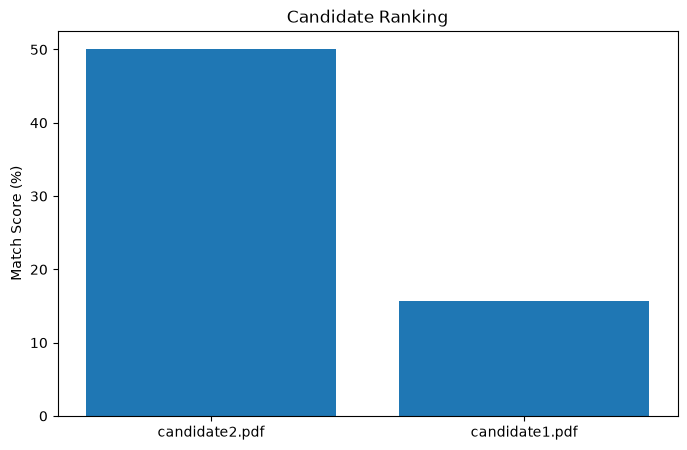

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    df["Candidate"],
    df["Score"]
)

plt.title("Candidate Ranking")
plt.ylabel("Match Score (%)")

plt.show()

In [40]:
pip install fpdf

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40770 sha256=211279d262b1f191eea7698867b36bd22eadc1ccb2df60b2bff4c046bb4cd867
  Stored in directory: c:\users\admin\appdata\local\packages\pythonsoftwarefoundation.python.3.11_qbz5n2kfra8p0\localcache\local\pip\cache\wheels\65\4f\66\bbda9866da446a72e206d6484cd97381cbc7859a7068541c36
Successfully built fpdf
Note: you may need to restart the kernel to use updated packages.


In [41]:
from fpdf import FPDF

pdf = FPDF()

pdf.add_page()

pdf.set_font(
    "Arial",
    size=12
)

pdf.cell(
    200,
    10,
    txt="Candidate Report",
    ln=True
)

pdf.output(
    "report.pdf"
)

''

In [42]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
